# EXPLORATORY DATA ANALYSIS

## Load cleaned data and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset from Notebook 2
df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

# Set a clean visual style for all charts
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded!
Shape: (5078336, 32)
Columns: ['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering']


## Class balance chart

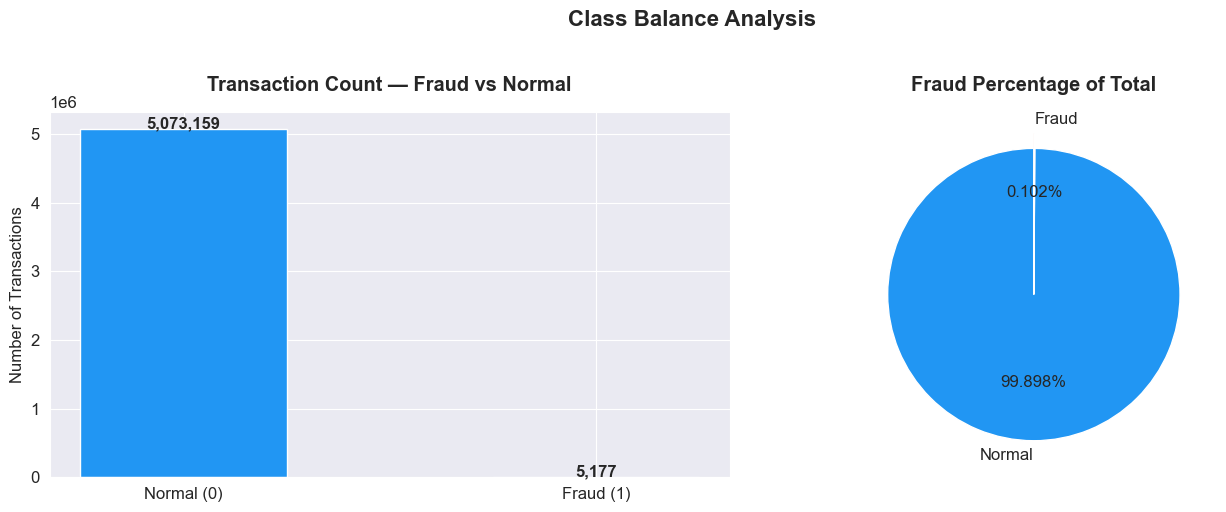


Normal transactions : 5,073,159 (99.898%)
Fraud transactions  : 5,177 (0.102%)
Imbalance ratio     : 979:1


In [2]:
# First and most important chart
# Shows how imbalanced our fraud vs normal data is

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Count bar chart ───────────────────────
counts = df['Is Laundering'].value_counts()
colors = ['#2196F3', '#E53935']

axes[0].bar(
    ['Normal (0)', 'Fraud (1)'],
    counts.values,
    color=colors,
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Transaction Count — Fraud vs Normal', 
                   fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Transactions')

# Add count labels on top of bars
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10000, f'{v:,}', 
                 ha='center', fontweight='bold')

# ── Chart 2: Pie chart ─────────────────────────────
axes[1].pie(
    counts.values,
    labels=['Normal', 'Fraud'],
    colors=colors,
    autopct='%1.3f%%',   # show percentage with 3 decimals
    startangle=90,
    explode=(0, 0.1)     # slightly pull out fraud slice
)
axes[1].set_title('Fraud Percentage of Total', 
                   fontweight='bold', pad=15)

plt.suptitle('Class Balance Analysis', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nNormal transactions : {counts[0]:,} ({counts[0]/len(df)*100:.3f}%)")
print(f"Fraud transactions  : {counts[1]:,} ({counts[1]/len(df)*100:.3f}%)")
print(f"Imbalance ratio     : {counts[0]//counts[1]}:1")

## Fraud by hour of day

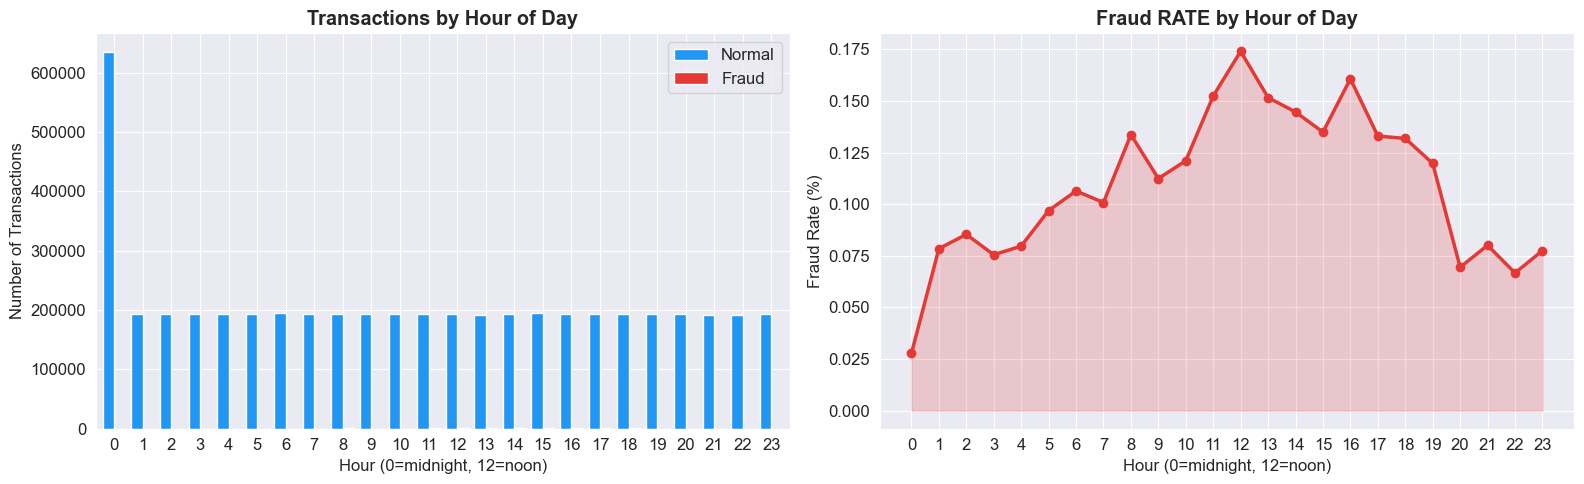

Top 5 most suspicious hours:
Hour
12    0.1741
16    0.1608
11    0.1525
13    0.1517
14    0.1447
Name: Is Laundering, dtype: float64


In [3]:
# Which hours see the most money laundering?
# This reveals the TIME PATTERN of fraudsters

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Transaction count by hour ────────────
hourly = df.groupby(['Hour', 'Is Laundering']).size().unstack(fill_value=0)

hourly.plot(
    kind='bar',
    ax=axes[0],
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.8
)
axes[0].set_title('Transactions by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0=midnight, 12=noon)')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend(['Normal', 'Fraud'])
axes[0].tick_params(axis='x', rotation=0)

# ── Chart 2: Fraud RATE by hour ────────────────────
# More useful — what % of transactions at each hour are fraud?
fraud_rate_hour = df.groupby('Hour')['Is Laundering'].mean() * 100

axes[1].plot(
    fraud_rate_hour.index,
    fraud_rate_hour.values,
    color='#E53935',
    linewidth=2.5,
    marker='o',
    markersize=6
)
axes[1].fill_between(
    fraud_rate_hour.index,
    fraud_rate_hour.values,
    alpha=0.2,
    color='#E53935'
)
axes[1].set_title('Fraud RATE by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (0=midnight, 12=noon)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Print the most suspicious hours
print("Top 5 most suspicious hours:")
print(fraud_rate_hour.nlargest(5).round(4))

## Fraud by payment format

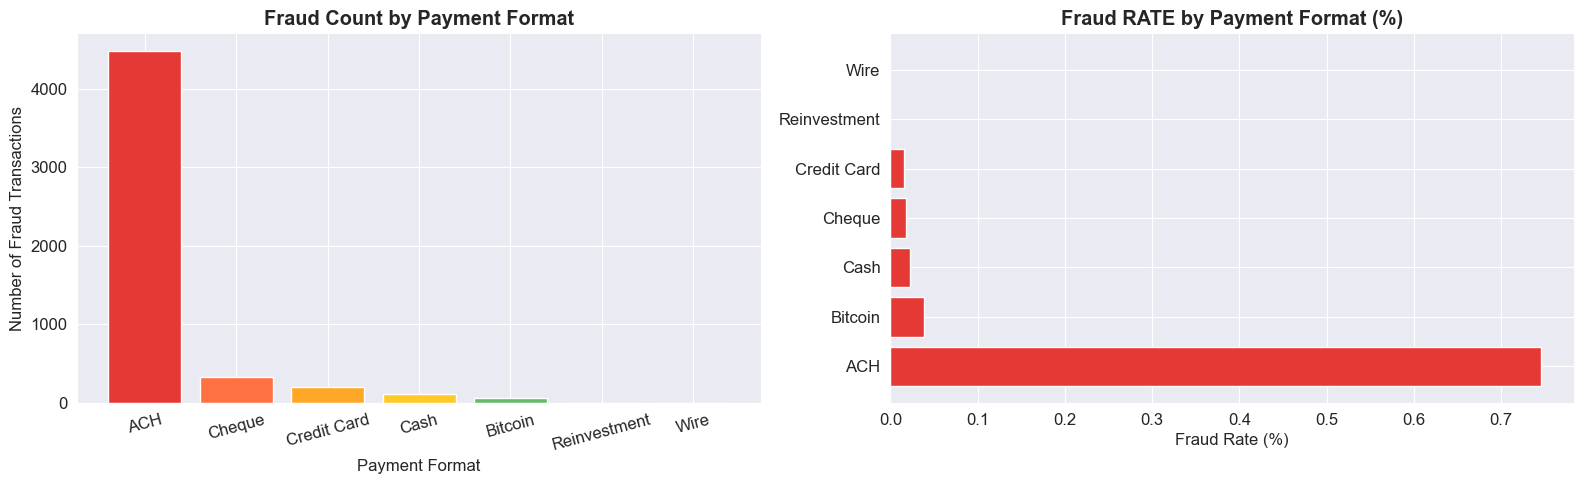


Fraud rate by payment format:
  ACH            : 0.746%  ███
  Bitcoin        : 0.038%  
  Cash           : 0.022%  
  Cheque         : 0.017%  
  Credit Card    : 0.016%  
  Reinvestment   : 0.000%  
  Wire           : 0.000%  


In [4]:
# Which payment method do launderers prefer?

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Total fraud count per format ──────────
fmt_fraud = df[df['Is Laundering']==1]['Payment Format'].value_counts() \
    if 'Payment Format' in df.columns else None

# Use OHE columns if original column was dropped
fmt_cols = [c for c in df.columns if c.startswith('fmt_')]
fmt_fraud_counts = {}
for col in fmt_cols:
    name = col.replace('fmt_', '')
    fraud_count = df[df['Is Laundering']==1][col].sum()
    fmt_fraud_counts[name] = fraud_count

fmt_series = pd.Series(fmt_fraud_counts).sort_values(ascending=False)

colors_fmt = ['#E53935','#FF7043','#FFA726','#FFCA28','#66BB6A','#42A5F5']
axes[0].bar(
    fmt_series.index,
    fmt_series.values,
    color=colors_fmt[:len(fmt_series)],
    edgecolor='white'
)
axes[0].set_title('Fraud Count by Payment Format', fontweight='bold')
axes[0].set_xlabel('Payment Format')
axes[0].set_ylabel('Number of Fraud Transactions')
axes[0].tick_params(axis='x', rotation=15)

# ── Chart 2: Fraud RATE per format ─────────────────
fmt_rate = {}
for col in fmt_cols:
    name = col.replace('fmt_', '')
    rate = df[df[col]==1]['Is Laundering'].mean() * 100
    fmt_rate[name] = rate

fmt_rate_series = pd.Series(fmt_rate).sort_values(ascending=False)

axes[1].barh(
    fmt_rate_series.index,
    fmt_rate_series.values,
    color='#E53935',
    edgecolor='white'
)
axes[1].set_title('Fraud RATE by Payment Format (%)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

print("\nFraud rate by payment format:")
for name, rate in fmt_rate_series.items():
    bar = '█' * int(rate * 5)
    print(f"  {name:15}: {rate:.3f}%  {bar}")

## Amount distribution fraud vs normal

C:\Users\tjain\AppData\Local\Temp\ipykernel_6804\2530006401.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


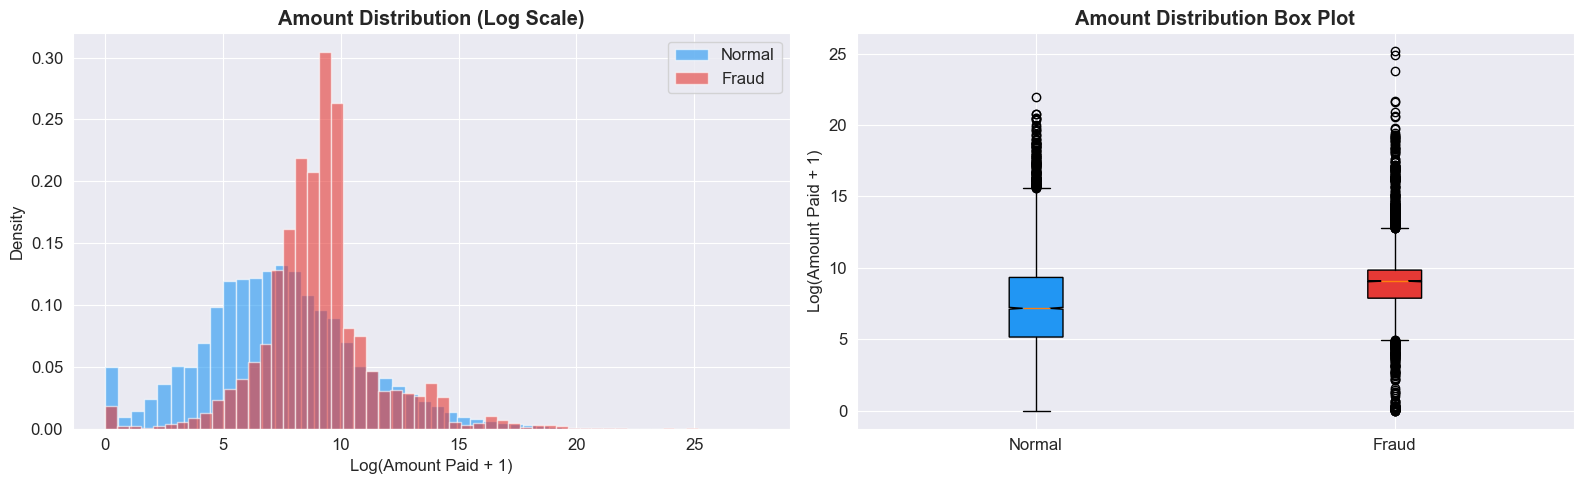

Amount statistics:

Normal — Mean: 4,477,008  Median: 1,411  Max: 1,046,302,363,293
Fraud  — Mean: 36,135,310  Median: 8,667  Max: 84,853,144,180


In [5]:
# How different are fraud amounts vs normal amounts?

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

normal_amounts = df[df['Is Laundering']==0]['Amount Paid']
fraud_amounts  = df[df['Is Laundering']==1]['Amount Paid']

# ── Chart 1: Log scale distribution ───────────────
# We use log scale because amounts range from ₹0.01 to ₹50,00,000
# Log scale makes both visible on same chart

axes[0].hist(
    np.log1p(normal_amounts),
    bins=50,
    color='#2196F3',
    alpha=0.6,
    label='Normal',
    density=True
)
axes[0].hist(
    np.log1p(fraud_amounts),
    bins=50,
    color='#E53935',
    alpha=0.6,
    label='Fraud',
    density=True
)
axes[0].set_title('Amount Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Log(Amount Paid + 1)')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── Chart 2: Box plot comparison ───────────────────
plot_data = [
    np.log1p(normal_amounts.sample(10000, random_state=42)),
    np.log1p(fraud_amounts)
]

bp = axes[1].boxplot(
    plot_data,
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    notch=True
)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#E53935')

axes[1].set_title('Amount Distribution Box Plot', fontweight='bold')
axes[1].set_ylabel('Log(Amount Paid + 1)')

plt.tight_layout()
plt.show()

print("Amount statistics:")
print(f"\nNormal — Mean: {normal_amounts.mean():,.0f}  "
      f"Median: {normal_amounts.median():,.0f}  "
      f"Max: {normal_amounts.max():,.0f}")
print(f"Fraud  — Mean: {fraud_amounts.mean():,.0f}  "
      f"Median: {fraud_amounts.median():,.0f}  "
      f"Max: {fraud_amounts.max():,.0f}")

## Cross bank and self transfer

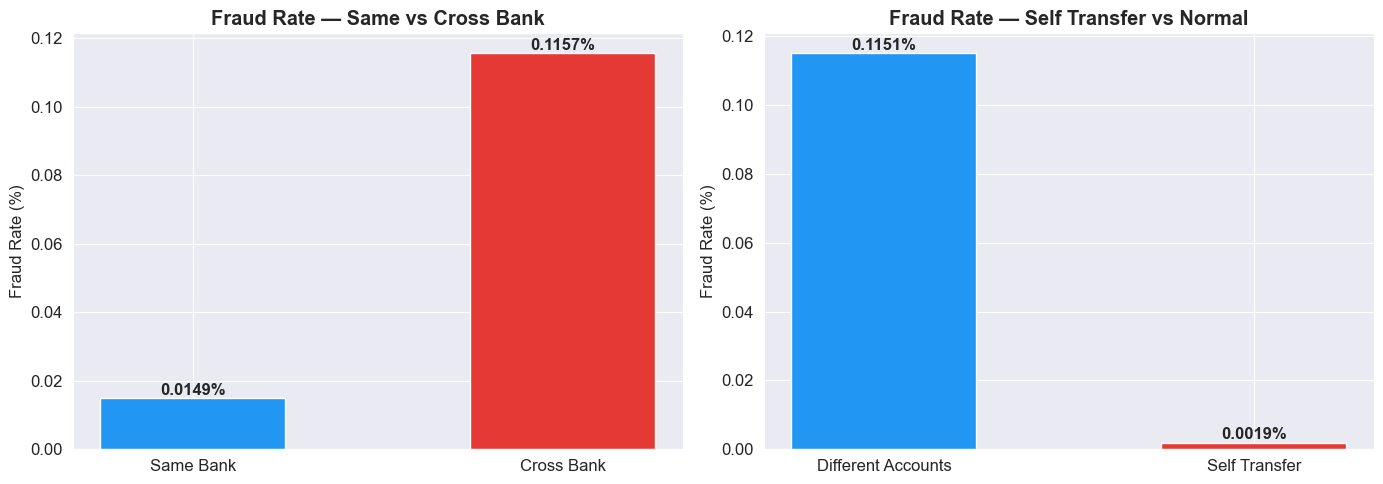

Cross bank fraud rate:
is_cross_bank
0    0.0149
1    0.1157
Name: Is Laundering, dtype: float64

Self transfer fraud rate:
is_self_transfer
0    0.1151
1    0.0019
Name: Is Laundering, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Cross bank fraud rate ─────────────────
cross_bank_rate = df.groupby('is_cross_bank')['Is Laundering'].mean() * 100

axes[0].bar(
    ['Same Bank', 'Cross Bank'],
    cross_bank_rate.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Fraud Rate — Same vs Cross Bank', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(cross_bank_rate.values):
    axes[0].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontweight='bold')

# ── Chart 2: Self transfer fraud rate ──────────────
self_transfer_rate = df.groupby('is_self_transfer')['Is Laundering'].mean() * 100

axes[1].bar(
    ['Different Accounts', 'Self Transfer'],
    self_transfer_rate.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Fraud Rate — Self Transfer vs Normal', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(self_transfer_rate.values):
    axes[1].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Cross bank fraud rate:")
print(cross_bank_rate.round(4))
print("\nSelf transfer fraud rate:")
print(self_transfer_rate.round(4))

## Outlier score Vs fraud rate

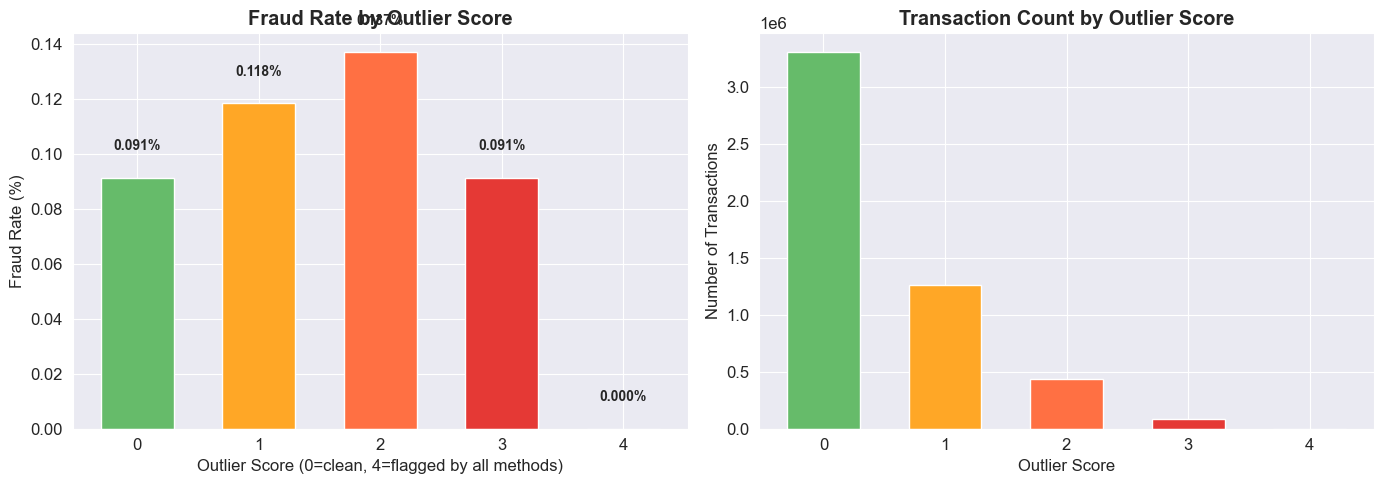


Fraud rate by outlier score:
  Score 0: 0.0914%    (3,301,810 transactions)
  Score 1: 0.1184%    (1,256,373 transactions)
  Score 2: 0.1370%    (431,377 transactions)
  Score 3: 0.0914%    (88,633 transactions)
  Score 4: 0.0000%    (143 transactions)


In [8]:
# Does higher outlier score = more fraud?
# This validates our outlier detection from Notebook 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Fraud rate by outlier score ───────────
fraud_by_score = df.groupby('outlier_score')['Is Laundering'].mean() * 100
count_by_score = df.groupby('outlier_score').size()

bars = axes[0].bar(
    fraud_by_score.index,
    fraud_by_score.values,
    color=['#66BB6A','#FFA726','#FF7043','#E53935','#B71C1C'],
    edgecolor='white',
    width=0.6
)
axes[0].set_title('Fraud Rate by Outlier Score', fontweight='bold')
axes[0].set_xlabel('Outlier Score (0=clean, 4=flagged by all methods)')
axes[0].set_ylabel('Fraud Rate (%)')

for bar, rate in zip(bars, fraud_by_score.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{rate:.3f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

# ── Chart 2: Transaction count by outlier score ────
axes[1].bar(
    count_by_score.index,
    count_by_score.values,
    color=['#66BB6A','#FFA726','#FF7043','#E53935','#B71C1C'],
    edgecolor='white',
    width=0.6
)
axes[1].set_title('Transaction Count by Outlier Score', fontweight='bold')
axes[1].set_xlabel('Outlier Score')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

print("\nFraud rate by outlier score:")
for score, rate in fraud_by_score.items():
    count = count_by_score[score]
    bar = '█' * int(rate * 5)
    print(f"  Score {score}: {rate:.4f}%  {bar}  ({count:,} transactions)")

## Correlation heatmap

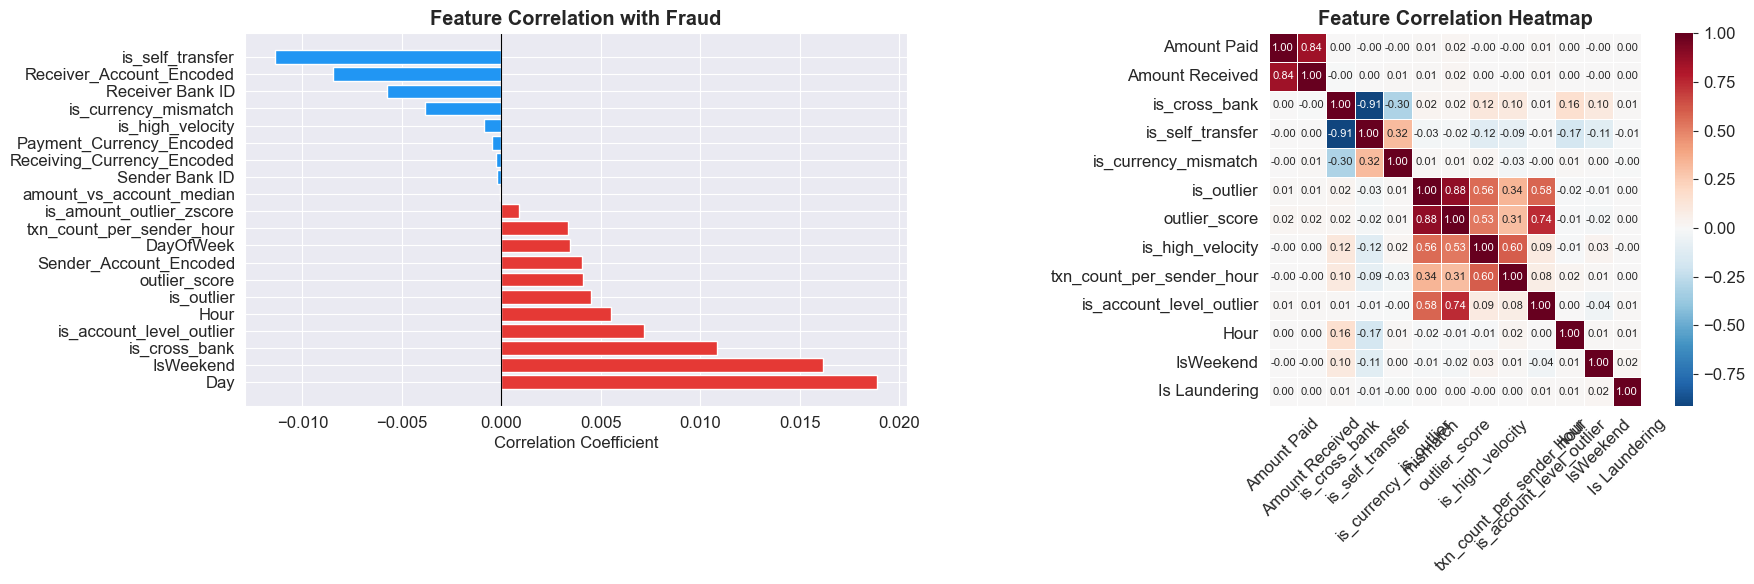


Top 10 features most correlated with fraud:
Day                          0.0189
IsWeekend                    0.0162
is_cross_bank                0.0108
is_account_level_outlier     0.0072
Hour                         0.0055
is_outlier                   0.0045
outlier_score                0.0041
Sender_Account_Encoded       0.0041
DayOfWeek                    0.0035
txn_count_per_sender_hour    0.0034
Name: Is Laundering, dtype: float64

Top 5 features least correlated (negative):
is_high_velocity           -0.0009
is_currency_mismatch       -0.0038
Receiver Bank ID           -0.0057
Receiver_Account_Encoded   -0.0085
is_self_transfer           -0.0114
Name: Is Laundering, dtype: float64


In [9]:
# Which features are most correlated with fraud?
# This tells us which features matter most for our ML model

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation with Is Laundering
correlations = df[numeric_cols].corr()['Is Laundering'].drop('Is Laundering')
correlations = correlations.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Chart 1: Top correlations bar chart ────────────
top_corr = pd.concat([
    correlations.head(10),    # top 10 positive
    correlations.tail(10)     # top 10 negative
])

colors_corr = ['#E53935' if v > 0 else '#2196F3' for v in top_corr.values]

axes[0].barh(
    top_corr.index,
    top_corr.values,
    color=colors_corr,
    edgecolor='white'
)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Fraud', fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')

# ── Chart 2: Full heatmap of key features ──────────
key_features = [
    'Amount Paid', 'Amount Received',
    'is_cross_bank', 'is_self_transfer',
    'is_currency_mismatch', 'is_outlier',
    'outlier_score', 'is_high_velocity',
    'txn_count_per_sender_hour',
    'is_account_level_outlier',
    'Hour', 'IsWeekend', 'Is Laundering'
]

# Only keep columns that exist in dataframe
key_features = [f for f in key_features if f in df.columns]

corr_matrix = df[key_features].corr()

sns.heatmap(
    corr_matrix,
    ax=axes[1],
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with fraud:")
print(correlations.head(10).round(4))
print("\nTop 5 features least correlated (negative):")
print(correlations.tail(5).round(4))

## Weekday vs wekend fraud

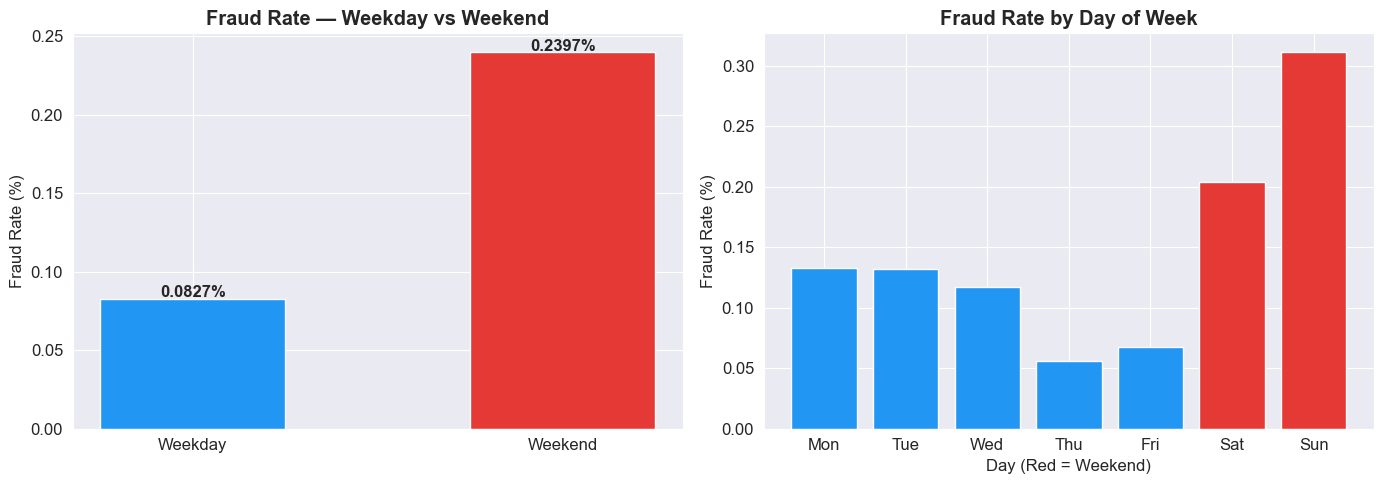

Fraud rate by day:
  Mon: 0.1327%
  Tue: 0.1321%
  Wed: 0.1174%
  Thu: 0.0556%
  Fri: 0.0673%
  Sat: 0.2040%
  Sun: 0.3113%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Fraud rate weekend vs weekday ─────────
weekend_fraud = df.groupby('IsWeekend')['Is Laundering'].mean() * 100

axes[0].bar(
    ['Weekday', 'Weekend'],
    weekend_fraud.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Fraud Rate — Weekday vs Weekend', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(weekend_fraud.values):
    axes[0].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontweight='bold')

# ── Chart 2: Fraud by day of week ──────────────────
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fraud_by_day = df.groupby('DayOfWeek')['Is Laundering'].mean() * 100

axes[1].bar(
    day_names,
    fraud_by_day.values,
    color=['#E53935' if i >= 5 else '#2196F3' for i in range(7)],
    edgecolor='white'
)
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Day (Red = Weekend)')

plt.tight_layout()
plt.show()

print("Fraud rate by day:")
for day, rate in zip(day_names, fraud_by_day.values):
    print(f"  {day}: {rate:.4f}%")

## EDA Summary

In [11]:
print("=" * 50)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 50)

print(f"""
DATASET
  Total transactions : {len(df):,}
  Fraud transactions : {df['Is Laundering'].sum():,}
  Fraud rate         : {df['Is Laundering'].mean()*100:.4f}%
  Imbalance ratio    : {(df['Is Laundering']==0).sum() // df['Is Laundering'].sum()}:1

AMOUNT INSIGHTS
  Normal avg amount  : {df[df['Is Laundering']==0]['Amount Paid'].mean():,.0f}
  Fraud avg amount   : {df[df['Is Laundering']==1]['Amount Paid'].mean():,.0f}
  Amount skewed      : YES — needs log transformation in preprocessing

OUTLIER INSIGHTS
  Outlier score 0 fraud rate : {df[df['outlier_score']==0]['Is Laundering'].mean()*100:.4f}%
  Outlier score 4 fraud rate : {df[df['outlier_score']==4]['Is Laundering'].mean()*100:.4f}% (if any)
  Outlier detection works    : YES

TIME INSIGHTS
  Most suspicious hour  : {df.groupby('Hour')['Is Laundering'].mean().idxmax()}:00
  Weekend more risky    : {df[df['IsWeekend']==1]['Is Laundering'].mean() > df[df['IsWeekend']==0]['Is Laundering'].mean()}

TOP CORRELATED FEATURES
""")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top5 = df[numeric_cols].corr()['Is Laundering'].drop('Is Laundering').abs().nlargest(5)
for feat, corr in top5.items():
    print(f"  {feat:35}: {corr:.4f}")

print("""
WHAT PREPROCESSING MUST DO (Notebook 4)
  1. Apply SMOTE to fix 981:1 imbalance
  2. Log transform Amount Paid (heavily skewed)
  3. Scale all numeric features
  4. Train test split 80/20
  5. Drop very low correlation features
""")

print("Notebook 3 — EDA Complete!")
print("Next → Notebook 4: Preprocessing")

EDA SUMMARY — KEY FINDINGS

DATASET
  Total transactions : 5,078,336
  Fraud transactions : 5,177
  Fraud rate         : 0.1019%
  Imbalance ratio    : 979:1

AMOUNT INSIGHTS
  Normal avg amount  : 4,477,008
  Fraud avg amount   : 36,135,310
  Amount skewed      : YES — needs log transformation in preprocessing

OUTLIER INSIGHTS
  Outlier score 0 fraud rate : 0.0914%
  Outlier score 4 fraud rate : 0.0000% (if any)
  Outlier detection works    : YES

TIME INSIGHTS
  Most suspicious hour  : 12:00
  Weekend more risky    : True

TOP CORRELATED FEATURES

  Day                                : 0.0189
  IsWeekend                          : 0.0162
  is_self_transfer                   : 0.0114
  is_cross_bank                      : 0.0108
  Receiver_Account_Encoded           : 0.0085

WHAT PREPROCESSING MUST DO (Notebook 4)
  1. Apply SMOTE to fix 981:1 imbalance
  2. Log transform Amount Paid (heavily skewed)
  3. Scale all numeric features
  4. Train test split 80/20
  5. Drop very low corre